# 03 — Neural architecture search

This notebook contains all the training runs of the study (Sec. 3 and Secs. 4.1–4.4 of the report). It proceeds in the four stages of the experimental protocol:

1. **Search** — random search over the space of MLPs: 300 architectures, one training run each (seed 0);
2. **Seed study** — 6 architectures trained with seeds 0–4, to measure the variability between runs;
3. **Re-evaluation** — 30 candidates trained with seeds 1–5; Pareto fronts on the means;
4. **Test** — the 9 selected architectures retrained with seeds 1–5 and evaluated on the test set.

**Input:** `dataset_finestre.npz` (from `01_data.ipynb`).

**Outputs:**

| File | Content |
|---|---|
| `risultati_nas.csv` | search, 300 architectures, seed 0, fixed budget of 20 epochs |
| `risultati_nas_v2.csv` | search after the early-stopping correction: **the reference file** |
| `rumore_semi.csv` | seed study: 6 architectures × seeds 0–4 |
| `multi_seed.csv` | re-evaluation: 30 candidates × seeds 1–5 |
| `risultati_test.csv` | test: 9 architectures × seeds 1–5, validation and test metrics |
| `punteggi_test.npz` | scores of the test runs on the test windows and on the straddling windows |
| `ricerca_300.pdf`, `frontiera_auc_ap.pdf` | Fig. 4 and Fig. 5 |

**Naming.** Identifiers, column names and printed messages are in Italian. The most frequent ones: `larghezze` = widths of the hidden layers (an architecture is written as `"16-128-16-128"`), `profondita` = depth, `n_param` = number of parameters, `epoca_migliore` = best epoch, `allena_e_valuta` = train and evaluate, `campiona` = sample, `chiave` = key, `semi` = seeds, `rumore` = noise, `fascia` = cost band, `candidate` = candidates, `calo` = drop, `frontiera` = front, `punteggi` = scores, `cav` = straddling windows.

The results are saved to file after every training run, so the long cells can be interrupted and resumed.

## 0. Setup

In [5]:
import copy
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score

# Dataset prepared in 01_data.ipynb (already normalised)
d = np.load("dataset_finestre.npz")
X_train, y_train = d["X_train"], d["y_train"]
X_val,   y_val   = d["X_val"],   d["y_val"]
X_test,  y_test  = d["X_test"],  d["y_test"]
X_cav_test = d["X_cav_test"]

# Device: the GPU of the Mac (MPS) if available, otherwise the CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Dispositivo:", device)

# Tensors for training and validation (test and control set are left aside until the end)
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32)
Xva = torch.tensor(X_val,   dtype=torch.float32)
yva = torch.tensor(y_val,   dtype=torch.float32)

print("Train:", tuple(Xtr.shape), "| Val:", tuple(Xva.shape))

Dispositivo: mps
Train: (47573, 30, 4) | Val: (28868, 30, 4)


## 1. Model and training protocol

All architectures, including the baseline, are trained by the same function, `allena_e_valuta`:

- the model is an MLP defined by the list of its hidden-layer widths;
- the loss is the binary cross-entropy weighted by `pos_weight` = negatives / positives in the training set;
- Adam with learning rate 10⁻³, mini-batches of 256 windows reshuffled at every epoch;
- after every epoch the AUC and the AP are computed on the validation set, and the weights with the highest validation AUC are kept;
- training stops after `patience` epochs without improvement of the validation AUC, or after `max_epochs`.

The seed fixes the initialisation of the weights and the order of the mini-batches.

In [13]:
# --- 1. An MLP built from a list of hidden-layer widths ---
class MLP(nn.Module):
    def __init__(self, larghezze, n_input=120):
        super().__init__()
        layers = [nn.Flatten()]                 # (batch, 30, 4) -> (batch, 120)
        dim_prec = n_input                      # input size of the next layer
        for h in larghezze:                     # one hidden layer for each width
            layers.append(nn.Linear(dim_prec, h))
            layers.append(nn.ReLU())
            dim_prec = h
        layers.append(nn.Linear(dim_prec, 1))   # output: one logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def conta_parametri(model):
    """Number of parameters (weights and biases) of a model."""
    return sum(p.numel() for p in model.parameters())


# --- 2. Objects shared by all training runs (computed once) ---
train_dataset = TensorDataset(Xtr, ytr)
pos_weight = torch.tensor([(ytr == 0).sum() / (ytr == 1).sum()]).to(device)
Xva_dev = Xva.to(device)       # the validation set stays on the GPU: no copy at every epoch
y_val_np = yva.numpy()


def valuta(model):
    """AUC and AP on the validation set."""
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xva_dev)).cpu().numpy()
    return roc_auc_score(y_val_np, probs), average_precision_score(y_val_np, probs)


# --- 3. Train one architecture and return the result of its best epoch ---
def allena_e_valuta(larghezze, max_epochs=100, patience=10, seed=0, lr=1e-3,
                    batch_size=256, verbose=False):
    """Train the MLP with the given widths and return (result dictionary, model).

    The best epoch is the one with the highest validation AUC; the AP is recorded at the
    same epoch. Training stops after `patience` consecutive epochs without improvement of
    the validation AUC, or after `max_epochs`. The returned model holds the weights of
    the best epoch.
    """
    # The seed fixes the weight initialisation and the order of the mini-batches
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = MLP(larghezze).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    best_auc, best_ap, best_epoch, best_state = -1.0, None, None, None
    senza_miglioramenti = 0                                  # epochs since the last improvement
    t0 = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        # One epoch: one pass over the training windows
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        auc, ap = valuta(model)
        if verbose:
            print(f"epoca {epoch:2d} | AUC val: {auc:.4f} | AP val: {ap:.4f}")

        if auc > best_auc:
            # Best validation AUC so far: store the weights and reset the counter
            best_auc, best_ap, best_epoch = auc, ap, epoch
            best_state = copy.deepcopy(model.state_dict())
            senza_miglioramenti = 0
        else:
            senza_miglioramenti += 1
            if senza_miglioramenti >= patience:              # patience exhausted: stop
                break

    tempo = time.perf_counter() - t0
    model.load_state_dict(best_state)                        # restore the weights of the best epoch

    risultato = {
        "larghezze": list(larghezze),
        "n_param": conta_parametri(model),
        "auc_val": best_auc,
        "ap_val": best_ap,
        "epoca_migliore": best_epoch,
        "epoche_totali": epoch,                              # number of epochs actually run
        "tempo_s": tempo,
    }
    return risultato, model

### First run: the baseline

The baseline `[64, 64]` with seed 0, with the validation metrics printed at every epoch. The AUC peaks at epoch 6 and the AP at epoch 12: the two metrics do not peak at the same epoch.

This cell and the search of the next section were run with a **fixed budget of 20 epochs and no early stopping**, which is what `max_epochs=20, patience=20` reproduces. (The output below was produced before the field `epoche_totali` was added to the result, so that line does not appear in it.)

In [7]:
res, model_base = allena_e_valuta([64, 64], verbose=True, max_epochs=20, patience=20)

print("\nRisultato:")
for k, v in res.items():
    print(f"  {k}: {v}")
print(f"\nStima grezza: 100 architetture ≈ {100 * res['tempo_s'] / 60:.0f} minuti")

epoca  1 | AUC val: 0.8553 | AP val: 0.2715
epoca  2 | AUC val: 0.8609 | AP val: 0.3020
epoca  3 | AUC val: 0.8576 | AP val: 0.3138
epoca  4 | AUC val: 0.8614 | AP val: 0.3356
epoca  5 | AUC val: 0.8615 | AP val: 0.3338
epoca  6 | AUC val: 0.8632 | AP val: 0.3339
epoca  7 | AUC val: 0.8578 | AP val: 0.3535
epoca  8 | AUC val: 0.8548 | AP val: 0.3569
epoca  9 | AUC val: 0.8521 | AP val: 0.3513
epoca 10 | AUC val: 0.8510 | AP val: 0.3484
epoca 11 | AUC val: 0.8552 | AP val: 0.3615
epoca 12 | AUC val: 0.8522 | AP val: 0.3627
epoca 13 | AUC val: 0.8492 | AP val: 0.3467
epoca 14 | AUC val: 0.8436 | AP val: 0.3296
epoca 15 | AUC val: 0.8464 | AP val: 0.3539
epoca 16 | AUC val: 0.8374 | AP val: 0.3347
epoca 17 | AUC val: 0.8453 | AP val: 0.3550
epoca 18 | AUC val: 0.8370 | AP val: 0.3247
epoca 19 | AUC val: 0.8444 | AP val: 0.3442
epoca 20 | AUC val: 0.8497 | AP val: 0.3309

Risultato:
  larghezze: [64, 64]
  n_param: 11969
  auc_val: 0.863167483113875
  ap_val: 0.33390326210082166
  epoca_mi

The largest network of the search space takes the same time as the baseline: the training time is almost independent of the architecture.

In [10]:
res_big, _ = allena_e_valuta([256, 256, 256, 256], max_epochs=20, patience=20)
print(f"Parametri: {res_big['n_param']} | tempo: {res_big['tempo_s']:.1f} s | "
      f"AUC val: {res_big['auc_val']:.4f} | epoca migliore: {res_big['epoca_migliore']}")

Parametri: 228609 | tempo: 13.8 s | AUC val: 0.8702 | epoca migliore: 4


## 2. Stage 1 — Search

### Search space and sampling

The search space contains the MLPs with 1 to 4 hidden layers, each with a width chosen from {16, 32, 64, 128, 256}: 780 architectures. An architecture is sampled hierarchically: first the depth, with equal probability, then each width, with equal probability.

In [8]:
PROFONDITA_POSSIBILI = [1, 2, 3, 4]
LARGHEZZE_POSSIBILI = [16, 32, 64, 128, 256]

def campiona_architettura(rng):
    """Sample one architecture, returned as the list of its hidden-layer widths."""
    L = rng.choice(PROFONDITA_POSSIBILI)                         # 1) depth, uniform
    return [rng.choice(LARGHEZZE_POSSIBILI) for _ in range(L)]   # 2) L independent widths

# Example: 8 sampled architectures
rng = random.Random(123)
for _ in range(8):
    print(campiona_architettura(rng))

[64]
[128]
[16, 16, 128]
[64, 16, 32]
[64, 256]
[32, 32, 16]
[16, 256, 128, 16]
[64]


### Random search (300 architectures, seed 0)

Architectures are sampled until 300 distinct ones have been evaluated; duplicates are discarded. Each architecture is trained once, with seed 0 and a fixed budget of 20 epochs. The result is appended to `risultati_nas.csv` after every run; if the file already exists, the search resumes from where it stopped.

In [11]:
FILE_RISULTATI = "risultati_nas.csv"
BUDGET = 300


def chiave(larghezze):
    """Represent an architecture as text, e.g. [64, 16, 256] -> '64-16-256'."""
    return "-".join(str(h) for h in larghezze)


def campiona_nuova(rng, gia_valutate, max_tentativi=10000):
    """Sample architectures until one that has not been evaluated yet is found."""
    for _ in range(max_tentativi):
        A = campiona_architettura(rng)
        if chiave(A) not in gia_valutate:
            return A
    raise RuntimeError("Nessuna architettura nuova trovata: spazio esaurito?")


# If the file already exists, resume from where the search stopped
if os.path.exists(FILE_RISULTATI):
    df_ris = pd.read_csv(FILE_RISULTATI)
    gia_valutate = set(df_ris["larghezze"])
    print(f"Ripresa: {len(gia_valutate)} architetture già valutate.")
else:
    df_ris = pd.DataFrame()
    gia_valutate = set()

rng = random.Random(123)
t_inizio = time.perf_counter()

while len(gia_valutate) < BUDGET:
    A = campiona_nuova(rng, gia_valutate)
    res, _ = allena_e_valuta(A, seed=0, max_epochs=20, patience=20)   # fixed budget of 20 epochs

    riga = {
        "larghezze": chiave(A),
        "profondita": len(A),
        "n_param": res["n_param"],
        "auc_val": res["auc_val"],
        "ap_val": res["ap_val"],
        "epoca_migliore": res["epoca_migliore"],
        "tempo_s": res["tempo_s"],
    }
    df_ris = pd.concat([df_ris, pd.DataFrame([riga])], ignore_index=True)
    df_ris.to_csv(FILE_RISULTATI, index=False)       # saved after every architecture
    gia_valutate.add(riga["larghezze"])

    minuti = (time.perf_counter() - t_inizio) / 60
    print(f"[{len(gia_valutate):3d}/{BUDGET}] {riga['larghezze']:>18s} | "
          f"param: {riga['n_param']:7d} | AUC: {riga['auc_val']:.4f} | "
          f"epoca: {riga['epoca_migliore']:2d} | {minuti:5.1f} min")

print("Ricerca completata.")

[  1/300]                 64 | param:    7809 | AUC: 0.8586 | epoca:  9 |   0.2 min
[  2/300]                128 | param:   15617 | AUC: 0.8532 | epoca: 10 |   0.3 min
[  3/300]          16-16-128 | param:    4513 | AUC: 0.8701 | epoca: 15 |   0.6 min
[  4/300]           64-16-32 | param:    9361 | AUC: 0.8601 | epoca:  4 |   0.8 min
[  5/300]             64-256 | param:   24641 | AUC: 0.8658 | epoca:  5 |   1.0 min
[  6/300]           32-32-16 | param:    5473 | AUC: 0.8685 | epoca: 13 |   1.2 min
[  7/300]      16-256-128-16 | param:   41265 | AUC: 0.8711 | epoca: 11 |   1.5 min
[  8/300]        16-16-16-32 | param:    3057 | AUC: 0.8666 | epoca: 17 |   1.7 min
[  9/300]              16-64 | param:    3089 | AUC: 0.8632 | epoca:  9 |   1.9 min
[ 10/300]     256-128-64-128 | param:   80577 | AUC: 0.8661 | epoca:  3 |   2.2 min
[ 11/300]         256-128-32 | param:   68033 | AUC: 0.8613 | epoca:  2 |   2.4 min
[ 12/300]         16-128-256 | param:   37393 | AUC: 0.8667 | epoca:  8 |   

### First look at the search results

Statistics of the 300 architectures as obtained with the fixed budget of 20 epochs, i.e. **before** the correction of the next cell. The values reported in the report are those after the correction (`risultati_nas_v2.csv`, checked in `05_verify_results.ipynb`).

The cell also counts the architectures whose best epoch is later than 10: with only 20 epochs, these may not have finished improving.

        auc_val    ap_val      n_param
count  300.0000  300.0000     300.0000
mean     0.8651    0.3619   36627.3467
std      0.0041    0.0296   34577.6571
min      0.8532    0.2856    1953.0000
25%      0.8619    0.3380   11853.0000
50%      0.8647    0.3652   24697.0000
75%      0.8678    0.3877   50769.0000
max      0.8795    0.4210  228609.0000

Per profondità:
           auc_val                        ap_val                        \
              mean     min     max count    mean     min     max count   
profondita                                                               
1           0.8568  0.8532  0.8593     5  0.3107  0.3007  0.3253     5   
2           0.8620  0.8588  0.8658    25  0.3409  0.2972  0.3937    25   
3           0.8645  0.8566  0.8795   102  0.3604  0.3028  0.4179   102   
4           0.8662  0.8585  0.8761   168  0.3674  0.2856  0.4210   168   

           epoca_migliore                
                     mean min max count  
profondita                   

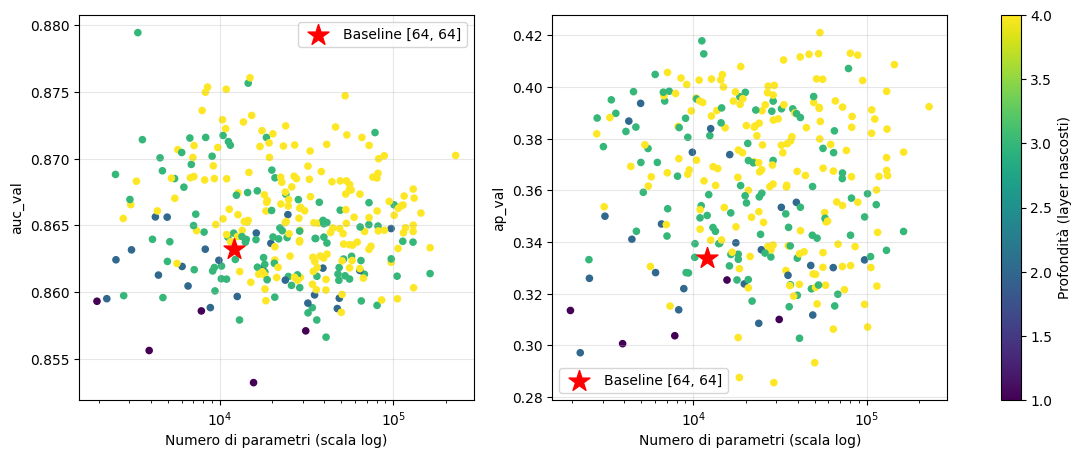

In [12]:
df_ris = pd.read_csv("risultati_nas.csv")

# Baseline for reference (same protocol, seed 0)
BASE_PARAM, BASE_AUC, BASE_AP = 11969, 0.8632, 0.3339

# 1. Overall statistics
print(df_ris[["auc_val", "ap_val", "n_param"]].describe().round(4))

# 2. By depth
print("\nPer profondità:")
print(df_ris.groupby("profondita")[["auc_val", "ap_val", "epoca_migliore"]]
      .agg(["mean", "min", "max", "count"]).round(4))

# 3. How many networks should be retrained with early stopping
print("\nEpoca migliore > 10:", (df_ris["epoca_migliore"] > 10).sum())
print("Epoca migliore = 20:", (df_ris["epoca_migliore"] == 20).sum())

# 4. The 10 best by AUC and the 10 smallest
print("\nTop 10 per AUC:")
print(df_ris.sort_values("auc_val", ascending=False).head(10)
      [["larghezze", "n_param", "auc_val", "ap_val", "epoca_migliore"]])
print("\nLe 10 più piccole:")
print(df_ris.sort_values("n_param").head(10)
      [["larghezze", "n_param", "auc_val", "ap_val", "epoca_migliore"]])

# 5. Plots: AUC and AP against the number of parameters (log scale), coloured by depth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, base in zip(axes, ["auc_val", "ap_val"], [BASE_AUC, BASE_AP]):
    sc = ax.scatter(df_ris["n_param"], df_ris[col], c=df_ris["profondita"],
                    cmap="viridis", s=20)
    ax.scatter([BASE_PARAM], [base], marker="*", s=250, color="red",
               label="Baseline [64, 64]")
    ax.set_xscale("log")
    ax.set_xlabel("Numero di parametri (scala log)")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.colorbar(sc, ax=axes, label="Profondità (layer nascosti)")
plt.show()

### Early-stopping correction

The 41 architectures whose best epoch was later than 10 are retrained with the final protocol (patience of 10 epochs, at most 100 epochs), again with seed 0. For all the other architectures the 20 epochs already include 10 epochs without improvement after the best one, so the final protocol gives the same result by construction.

The corrected results are saved in `risultati_nas_v2.csv`, which is the file used from here on. Of the 41 architectures, 32 are unchanged and 5 improve by training longer. The remaining 4 get a slightly lower AUC: their best epoch in the 20-epoch run came after more than 10 epochs without improvement, so the patience rule stops earlier, at a previous peak.

In [14]:
df_v2 = df_ris.copy()
da_rifare = df_v2[df_v2["epoca_migliore"] > 10].index
print("Architetture da riallenare:", len(da_rifare))

for n, i in enumerate(da_rifare, start=1):
    A = [int(h) for h in df_v2.loc[i, "larghezze"].split("-")]   # "16-16-64" -> [16, 16, 64]
    auc_vecchia = df_v2.loc[i, "auc_val"]

    res, _ = allena_e_valuta(A, seed=0)                          # final protocol (patience 10)

    df_v2.loc[i, "auc_val"] = res["auc_val"]
    df_v2.loc[i, "ap_val"] = res["ap_val"]
    df_v2.loc[i, "epoca_migliore"] = res["epoca_migliore"]
    df_v2.loc[i, "tempo_s"] = res["tempo_s"]
    df_v2.to_csv("risultati_nas_v2.csv", index=False)            # saved after every architecture

    print(f"[{n:2d}/{len(da_rifare)}] {df_v2.loc[i, 'larghezze']:>16s} | "
          f"AUC {auc_vecchia:.4f} -> {res['auc_val']:.4f} | "
          f"epoca migliore {res['epoca_migliore']:3d} su {res['epoche_totali']:3d}")

Architetture da riallenare: 41
[ 1/41]        16-16-128 | AUC 0.8701 -> 0.8701 | epoca migliore  15 su  25
[ 2/41]         32-32-16 | AUC 0.8685 -> 0.8685 | epoca migliore  13 su  23
[ 3/41]    16-256-128-16 | AUC 0.8711 -> 0.8711 | epoca migliore  11 su  21
[ 4/41]      16-16-16-32 | AUC 0.8666 -> 0.8666 | epoca migliore  17 su  27
[ 5/41]        16-32-256 | AUC 0.8713 -> 0.8706 | epoca migliore   5 su  15
[ 6/41]               16 | AUC 0.8593 -> 0.8593 | epoca migliore  19 su  29
[ 7/41]    16-256-16-128 | AUC 0.8674 -> 0.8674 | epoca migliore  19 su  29
[ 8/41]           16-128 | AUC 0.8656 -> 0.8656 | epoca migliore  19 su  29
[ 9/41]        16-32-128 | AUC 0.8696 -> 0.8696 | epoca migliore  15 su  25
[10/41]         16-16-32 | AUC 0.8597 -> 0.8629 | epoca migliore  24 su  34
[11/41]            16-16 | AUC 0.8595 -> 0.8638 | epoca migliore  31 su  41
[12/41]    16-256-256-32 | AUC 0.8686 -> 0.8686 | epoca migliore  12 su  22
[13/41]         16-32-32 | AUC 0.8714 -> 0.8714 | epoca m

### Search results (Fig. 4)

Validation AUC (seed 0) of the 300 architectures against the number of parameters, coloured by depth, from the corrected file.

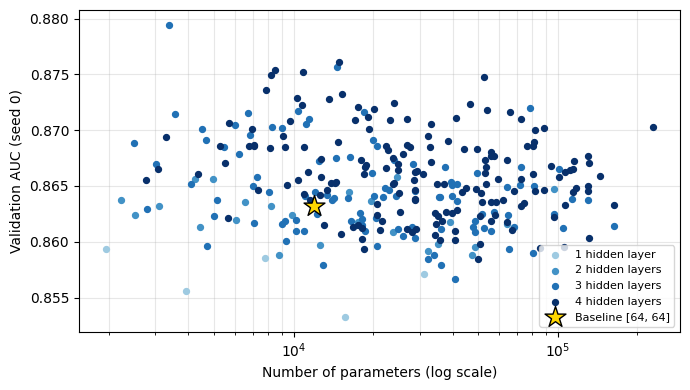

In [1]:
ris = pd.read_csv("risultati_nas_v2.csv", dtype={"larghezze": str})
ris["profondita"] = ris["larghezze"].str.count("-") + 1          # depth = number of widths

colori = {1: "#9ecae1", 2: "#4292c6", 3: "#2171b5", 4: "#08306b"}   # light -> dark with depth
fig, ax = plt.subplots(figsize=(7, 4))
for L, c in colori.items():
    s = ris[ris["profondita"] == L]
    ax.scatter(s["n_param"], s["auc_val"], s=18, color=c,
               label=f"{L} hidden layer" + ("s" if L > 1 else ""), zorder=2)
b = ris[ris["larghezze"] == "64-64"].iloc[0]                     # the baseline
ax.scatter(b["n_param"], b["auc_val"], marker="*", s=250, color="gold",
           edgecolor="black", label="Baseline [64, 64]", zorder=3)
ax.set_xscale("log")
ax.set_xlabel("Number of parameters (log scale)")
ax.set_ylabel("Validation AUC (seed 0)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("ricerca_300.pdf", bbox_inches="tight")
plt.show()

## 3. Stage 2 — Seed study

How much does the result of one architecture change with the seed? Six architectures are trained with seeds 0–4: the smallest network, the baseline, the largest network, an intermediate one (`32-32-32`), the best of the search (`16-16-64`) and a small network with a high single-seed AUC (`16-16-16`).

In [16]:
ARCH_RUMORE = [[16], [16, 16, 16], [64, 64], [16, 16, 64], [32, 32, 32], [256, 256, 256, 256]]
SEMI = [0, 1, 2, 3, 4]

righe = []
for A in ARCH_RUMORE:
    for s in SEMI:
        res, _ = allena_e_valuta(A, seed=s)
        righe.append({
            "larghezze": chiave(A),
            "seed": s,
            "n_param": res["n_param"],
            "auc_val": res["auc_val"],
            "ap_val": res["ap_val"],
            "epoca_migliore": res["epoca_migliore"],
        })
        print(f"{chiave(A):>16s} | seed {s} | AUC {res['auc_val']:.4f} | "
              f"AP {res['ap_val']:.4f} | epoca {res['epoca_migliore']}")

df_rum = pd.DataFrame(righe)
df_rum.to_csv("rumore_semi.csv", index=False)

# Mean, standard deviation and range over the five seeds, for each architecture
print("\nPer architettura (su 5 semi):")
print(df_rum.groupby("larghezze")[["auc_val", "ap_val"]]
      .agg(["mean", "std", "min", "max"]).round(4))

              16 | seed 0 | AUC 0.8593 | AP 0.3135 | epoca 19
              16 | seed 1 | AUC 0.8569 | AP 0.3062 | epoca 13
              16 | seed 2 | AUC 0.8586 | AP 0.3110 | epoca 46
              16 | seed 3 | AUC 0.8571 | AP 0.2939 | epoca 13
              16 | seed 4 | AUC 0.8602 | AP 0.3188 | epoca 26
        16-16-16 | seed 0 | AUC 0.8688 | AP 0.3332 | epoca 15
        16-16-16 | seed 1 | AUC 0.8745 | AP 0.3763 | epoca 33
        16-16-16 | seed 2 | AUC 0.8717 | AP 0.4190 | epoca 15
        16-16-16 | seed 3 | AUC 0.8695 | AP 0.4021 | epoca 19
        16-16-16 | seed 4 | AUC 0.8659 | AP 0.3553 | epoca 10
           64-64 | seed 0 | AUC 0.8632 | AP 0.3339 | epoca 6
           64-64 | seed 1 | AUC 0.8615 | AP 0.3444 | epoca 4
           64-64 | seed 2 | AUC 0.8632 | AP 0.3469 | epoca 7
           64-64 | seed 3 | AUC 0.8635 | AP 0.3483 | epoca 6
           64-64 | seed 4 | AUC 0.8642 | AP 0.3378 | epoca 5
        16-16-64 | seed 0 | AUC 0.8795 | AP 0.3950 | epoca 17
        16-16

## 4. Stage 3 — Re-evaluation with five seeds

### Selection of the candidates

The parameter axis is divided into seven bands whose width doubles (1,900–4,000, …, 128,000–256,000). In each band the four architectures with the highest single-seed AUC are selected; the smallest network (`16`) and the baseline (`64-64`) are added, for a total of 30 candidates.

In [17]:
# The column of the architectures is read as text (dtype=str), so that "16" stays a string
df_ris = pd.read_csv("risultati_nas_v2.csv", dtype={"larghezze": str})
df_rum = pd.read_csv("rumore_semi.csv", dtype={"larghezze": str})

# Cost bands (number of parameters) and the 4 best architectures by AUC in each of them
BORDI = [1900, 4000, 8000, 16000, 32000, 64000, 128000, 256000]
df_ris["fascia"] = pd.cut(df_ris["n_param"], bins=BORDI)
top_per_fascia = (df_ris.sort_values("auc_val", ascending=False)
                        .groupby("fascia", observed=True).head(4))
# Add the smallest network and the baseline, then sort by number of parameters
candidate = set(top_per_fascia["larghezze"]) | {"16", "64-64"}
param_di = dict(zip(df_ris["larghezze"], df_ris["n_param"]))
candidate = sorted(candidate, key=lambda k: param_di[k])
print(f"Candidate: {len(candidate)}")
for k in candidate:
    print(f"  {k:>18s} | {param_di[k]:7d} parametri")

Candidate: 30
                  16 |    1953 parametri
            16-16-16 |    2497 parametri
         16-32-16-16 |    3297 parametri
            16-16-64 |    3361 parametri
            16-32-32 |    3569 parametri
         16-32-32-64 |    5713 parametri
            32-32-32 |    6017 parametri
           32-16-128 |    6705 parametri
        16-32-32-128 |    7889 parametri
       16-128-16-128 |    8481 parametri
        16-32-128-32 |   10865 parametri
               64-64 |   11969 parametri
           16-256-32 |   14545 parametri
        32-16-128-64 |   14897 parametri
        32-32-128-64 |   17473 parametri
           64-32-256 |   18529 parametri
        16-16-64-256 |   20193 parametri
        32-32-64-256 |   23937 parametri
       16-256-128-16 |   41265 parametri
       32-32-256-128 |   46401 parametri
       16-64-256-128 |   52689 parametri
      16-128-128-256 |   53905 parametri
      64-128-128-256 |   65857 parametri
      16-256-128-256 |   72465 parametri
  

### Training the candidates with seeds 1–5

Seed 0 is not used: the candidates were selected on its results, so including it would bias their means upwards. The runs with seeds 1–4 already made in the seed study are reused; the remaining ones are trained here and saved to `multi_seed.csv` after every run.

In [18]:
SEMI = [1, 2, 3, 4, 5]
FILE_MS = "multi_seed.csv"
# Start from the runs already available: the saved file if it exists,
# otherwise the runs of the seed study with seeds 1-4
if os.path.exists(FILE_MS):
    righe = pd.read_csv(FILE_MS, dtype={"larghezze": str}).to_dict("records")
else:
    righe = df_rum[df_rum["seed"].isin(SEMI)].to_dict("records")
fatte = {(r["larghezze"], r["seed"]) for r in righe}
da_fare = [(k, s) for k in candidate for s in SEMI if (k, s) not in fatte]
print(f"Addestramenti da fare: {len(da_fare)}")

t_inizio = time.perf_counter()
for n, (k, s) in enumerate(da_fare, start=1):
    A = [int(h) for h in k.split("-")]
    res, _ = allena_e_valuta(A, seed=s)
    righe.append({"larghezze": k, "seed": s, "n_param": res["n_param"],
                  "auc_val": res["auc_val"], "ap_val": res["ap_val"],
                  "epoca_migliore": res["epoca_migliore"]})
    pd.DataFrame(righe).to_csv(FILE_MS, index=False)
    minuti = (time.perf_counter() - t_inizio) / 60
    print(f"[{n:3d}/{len(da_fare)}] {k:>18s} | seed {s} | AUC {res['auc_val']:.4f} | {minuti:5.1f} min")

Addestramenti da fare: 126
[  1/126]                 16 | seed 5 | AUC 0.8594 |   0.3 min
[  2/126]           16-16-16 | seed 5 | AUC 0.8714 |   0.6 min
[  3/126]        16-32-16-16 | seed 1 | AUC 0.8684 |   0.9 min
[  4/126]        16-32-16-16 | seed 2 | AUC 0.8662 |   1.2 min
[  5/126]        16-32-16-16 | seed 3 | AUC 0.8745 |   1.5 min
[  6/126]        16-32-16-16 | seed 4 | AUC 0.8708 |   1.8 min
[  7/126]        16-32-16-16 | seed 5 | AUC 0.8771 |   2.1 min
[  8/126]           16-16-64 | seed 5 | AUC 0.8672 |   2.4 min
[  9/126]           16-32-32 | seed 1 | AUC 0.8650 |   2.6 min
[ 10/126]           16-32-32 | seed 2 | AUC 0.8715 |   2.8 min
[ 11/126]           16-32-32 | seed 3 | AUC 0.8688 |   3.0 min
[ 12/126]           16-32-32 | seed 4 | AUC 0.8653 |   3.3 min
[ 13/126]           16-32-32 | seed 5 | AUC 0.8621 |   3.6 min
[ 14/126]        16-32-32-64 | seed 1 | AUC 0.8643 |   3.8 min
[ 15/126]        16-32-32-64 | seed 2 | AUC 0.8693 |   4.1 min
[ 16/126]        16-32-32-64

### Pareto front on the mean AUC (Table 8, Table 11)

For each candidate: mean, standard deviation and standard error of the validation AUC over the five seeds, and the drop with respect to the single-seed value of the search. The Pareto front is found by sorting the candidates by number of parameters and keeping each one whose mean AUC exceeds that of all the cheaper ones.

In [19]:
df_ms = pd.read_csv("multi_seed.csv", dtype={"larghezze": str})
df_ms = df_ms[df_ms["larghezze"].isin(candidate) & df_ms["seed"].isin(SEMI)]

# Statistics over the five seeds, one row per candidate, sorted by number of parameters
stat = (df_ms.groupby("larghezze")
             .agg(n_param=("n_param", "first"),
                  n_semi=("seed", "count"),
                  auc_media=("auc_val", "mean"),
                  auc_std=("auc_val", "std"),
                  ap_media=("ap_val", "mean"),
                  ap_std=("ap_val", "std"),
                  epoca_media=("epoca_migliore", "mean"))
             .sort_values("n_param")
             .reset_index())
stat["auc_se"] = stat["auc_std"] / np.sqrt(stat["n_semi"])    # standard error of the mean

# Comparison with the value of seed 0 (the one used to select the candidates)
auc_seed0 = dict(zip(df_ris["larghezze"], df_ris["auc_val"]))
stat["auc_seed0"] = stat["larghezze"].map(auc_seed0)
stat["calo"] = stat["auc_seed0"] - stat["auc_media"]          # positive = worse with new seeds

# Pareto set on the means: going through the candidates by increasing cost,
# keep each one that is better than all the cheaper ones
miglior_auc_finora = -1.0
frontiera = []
for _, r in stat.iterrows():
    if r["auc_media"] > miglior_auc_finora:
        frontiera.append(r["larghezze"])
        miglior_auc_finora = r["auc_media"]
stat["pareto"] = stat["larghezze"].isin(frontiera)

print(stat[["larghezze", "n_param", "n_semi", "auc_media", "auc_std", "auc_se",
            "auc_seed0", "calo", "ap_media", "epoca_media", "pareto"]]
      .to_string(index=False, float_format="%.4f"))

      larghezze  n_param  n_semi  auc_media  auc_std  auc_se  auc_seed0    calo  ap_media  epoca_media  pareto
             16     1953       5     0.8584   0.0014  0.0006     0.8593  0.0009    0.3107      24.4000    True
       16-16-16     2497       5     0.8706   0.0031  0.0014     0.8688 -0.0018    0.3849      19.2000    True
    16-32-16-16     3297       5     0.8714   0.0044  0.0020     0.8694 -0.0020    0.3951      20.4000    True
       16-16-64     3361       5     0.8688   0.0027  0.0012     0.8795  0.0107    0.3920      16.4000   False
       16-32-32     3569       5     0.8665   0.0037  0.0016     0.8714  0.0049    0.3711      11.0000   False
    16-32-32-64     5713       5     0.8698   0.0038  0.0017     0.8707  0.0009    0.4008      16.4000   False
       32-32-32     6017       5     0.8646   0.0041  0.0018     0.8705  0.0059    0.3544       6.2000   False
      32-16-128     6705       5     0.8697   0.0027  0.0012     0.8716  0.0019    0.3889       9.4000   False
 

### Pareto front on the mean AP (robustness check)

The same construction, with the AP in place of the AUC.

In [21]:
stat["ap_se"] = stat["ap_std"] / np.sqrt(stat["n_semi"])      # standard error of the mean

miglior_ap_finora = -1.0
frontiera_ap = []
for _, r in stat.iterrows():
    if r["ap_media"] > miglior_ap_finora:
        frontiera_ap.append(r["larghezze"])
        miglior_ap_finora = r["ap_media"]
stat["pareto_ap"] = stat["larghezze"].isin(frontiera_ap)

print(stat[["larghezze", "n_param", "ap_media", "ap_std", "ap_se", "pareto_ap", "pareto"]]
      .to_string(index=False, float_format="%.4f"))

      larghezze  n_param  ap_media  ap_std  ap_se  pareto_ap  pareto
             16     1953    0.3107  0.0116 0.0052       True    True
       16-16-16     2497    0.3849  0.0254 0.0114       True    True
    16-32-16-16     3297    0.3951  0.0192 0.0086       True    True
       16-16-64     3361    0.3920  0.0053 0.0024      False   False
       16-32-32     3569    0.3711  0.0202 0.0090      False   False
    16-32-32-64     5713    0.4008  0.0075 0.0033       True   False
       32-32-32     6017    0.3544  0.0227 0.0101      False   False
      32-16-128     6705    0.3889  0.0103 0.0046      False   False
   16-32-32-128     7889    0.3927  0.0285 0.0127      False   False
  16-128-16-128     8481    0.4129  0.0081 0.0036       True    True
   16-32-128-32    10865    0.3994  0.0123 0.0055      False   False
          64-64    11969    0.3440  0.0041 0.0018      False   False
      16-256-32    14545    0.3973  0.0097 0.0043      False   False
   32-16-128-64    14897    0.3818

### The two fronts (Fig. 5)

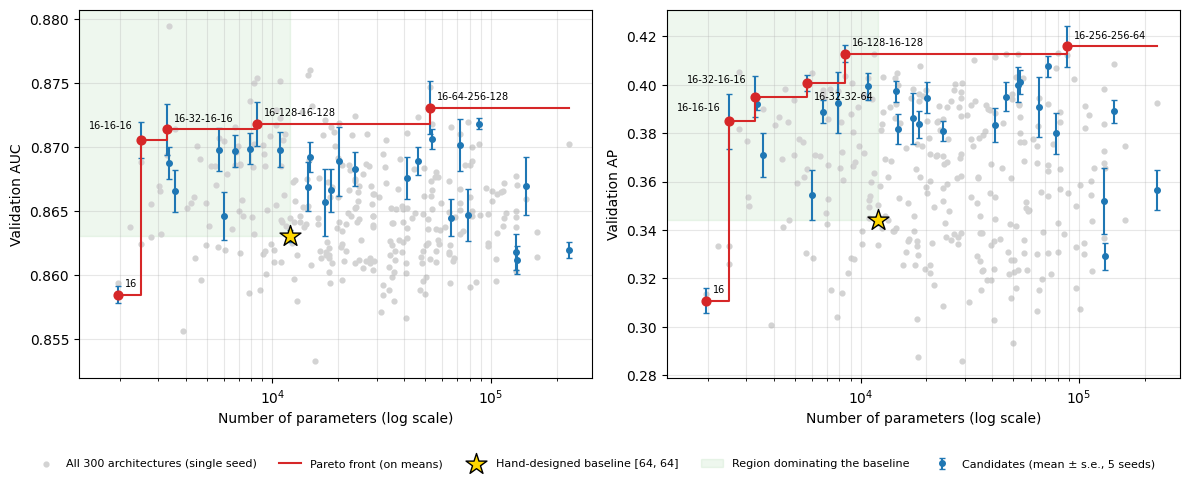

In [24]:
def disegna_pannello(ax, col_singolo, col_media, col_se, col_pareto, ylabel, spostamenti):
    """Draw one panel: the 300 architectures of the search, the candidates with their
    error bars, the Pareto front, the baseline and the region that dominates it.
    `spostamenti` gives the offsets of the labels of the architectures on the front."""
    # The 300 architectures of the search (single seed)
    ax.scatter(df_ris["n_param"], df_ris[col_singolo], s=12, color="lightgray",
               label="All 300 architectures (single seed)", zorder=1)
    # The candidates: mean and standard error over five seeds
    ax.errorbar(stat["n_param"], stat[col_media], yerr=stat[col_se],
                fmt="o", ms=4, color="tab:blue", capsize=2,
                label="Candidates (mean ± s.e., 5 seeds)", zorder=2)
    # The Pareto front as a step line, extended to the right edge of the search space
    fr = stat[stat[col_pareto]]
    x_fr = list(fr["n_param"]) + [df_ris["n_param"].max()]
    y_fr = list(fr[col_media]) + [fr[col_media].iloc[-1]]
    ax.plot(x_fr, y_fr, drawstyle="steps-post", color="tab:red", lw=1.5,
            label="Pareto front (on means)", zorder=3)
    ax.scatter(fr["n_param"], fr[col_media], s=40, color="tab:red", zorder=4)
    for _, r in fr.iterrows():
        dx, dy = spostamenti.get(r["larghezze"], (5, 6))
        ax.annotate(r["larghezze"], (r["n_param"], r[col_media]),
                    textcoords="offset points", xytext=(dx, dy), fontsize=7,
                    ha="right" if dx < 0 else "left")
    # The baseline
    b = stat[stat["larghezze"] == "64-64"].iloc[0]
    ax.scatter(b["n_param"], b[col_media], marker="*", s=250, color="gold",
               edgecolor="black", label="Hand-designed baseline [64, 64]", zorder=5)
    ax.set_xscale("log")
    ax.set_xlabel("Number of parameters (log scale)")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.3)
    # Region that dominates the baseline: fewer parameters and a higher metric
    x0, x1 = 1300, ax.get_xlim()[1]
    y0, y1 = ax.get_ylim()
    ax.fill_between([x0, b["n_param"]], b[col_media], y1, color="tab:green",
                    alpha=0.08, zorder=0, label="Region dominating the baseline")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
disegna_pannello(ax1, "auc_val", "auc_media", "auc_se", "pareto", "Validation AUC",
                 spostamenti={"16-16-16": (-6, 8)})
disegna_pannello(ax2, "ap_val", "ap_media", "ap_se", "pareto_ap", "Validation AP",
                 spostamenti={"16-16-16": (-6, 8), "16-32-16-16": (-6, 10),
                              "16-32-32-64": (5, -12)})
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=8, frameon=False)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig("frontiera_auc_ap.pdf", bbox_inches="tight")
plt.show()

## 5. Stage 4 — Evaluation on the test set

The test set is used only here. The architectures to test are fixed beforehand: those on at least one of the two fronts (AUC or AP), the baseline and the largest network.

In [25]:
# Test windows and straddling windows of the test set (control set)
d = np.load("dataset_finestre.npz")
X_test, y_test, X_cav = d["X_test"], d["y_test"], d["X_cav_test"]
print("forme:", X_test.shape, X_cav.shape)
print("medie test:", X_test.mean(axis=(0, 1)).round(3))
print("medie cav: ", X_cav.mean(axis=(0, 1)).round(3))

forme: (27920, 30, 4) (468, 30, 4)
medie test: [-0.09   0.049  0.002 -0.009]
medie cav:  [ 0.14  -0.911  0.331  0.043]


The trained networks of the re-evaluation were not stored, so the nine architectures are retrained with the same seeds 1–5. For each run the cell prints the difference between the validation AUC obtained now and the one of the re-evaluation (`diff`): it is zero in all 45 runs, i.e. the runs are reproduced exactly.

For each run we save the test AUC and AP in `risultati_test.csv`, and the scores on the test windows and on the straddling windows in `punteggi_test.npz` (used by `04_test_analysis.ipynb`).

In [26]:
Xte_dev = torch.tensor(X_test, dtype=torch.float32).to(device)
Xcav_dev = torch.tensor(X_cav, dtype=torch.float32).to(device)

DA_TESTARE = ["16", "16-16-16", "16-32-16-16", "16-32-32-64", "16-128-16-128",
              "64-64", "16-64-256-128", "16-256-256-64", "256-256-256-256"]
SEMI = [1, 2, 3, 4, 5]
# Validation AUC of the same runs in the re-evaluation, to check reproducibility
auc_val_prima = {(r["larghezze"], r["seed"]): r["auc_val"] for _, r in df_ms.iterrows()}

def punteggi(model, X_dev):
    """Scores in (0, 1) assigned by the model to the given windows."""
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X_dev)).cpu().numpy()

righe_test = []
punteggi_salvati = {}
for k in DA_TESTARE:
    for s in SEMI:
        A = [int(h) for h in k.split("-")]
        res, model = allena_e_valuta(A, seed=s)
        p_te = punteggi(model, Xte_dev)         # scores on the test windows
        p_cav = punteggi(model, Xcav_dev)       # scores on the straddling windows
        riga = {"larghezze": k, "seed": s, "n_param": res["n_param"],
                "auc_val": res["auc_val"], "ap_val": res["ap_val"],
                "auc_test": roc_auc_score(y_test, p_te),
                "ap_test": average_precision_score(y_test, p_te),
                "epoca_migliore": res["epoca_migliore"]}
        righe_test.append(riga)
        punteggi_salvati[f"{k}_seed{s}_test"] = p_te
        punteggi_salvati[f"{k}_seed{s}_cav"] = p_cav
        pd.DataFrame(righe_test).to_csv("risultati_test.csv", index=False)
        diff = res["auc_val"] - auc_val_prima[(k, s)]
        print(f"{k:>16s} | seed {s} | AUC val {res['auc_val']:.4f} (diff {diff:+.4f}) | "
              f"AUC test {riga['auc_test']:.4f} | AP test {riga['ap_test']:.4f}")

np.savez_compressed("punteggi_test.npz", y_test=y_test, **punteggi_salvati)

              16 | seed 1 | AUC val 0.8569 (diff +0.0000) | AUC test 0.8876 | AP test 0.2839
              16 | seed 2 | AUC val 0.8586 (diff +0.0000) | AUC test 0.8870 | AP test 0.2983
              16 | seed 3 | AUC val 0.8571 (diff +0.0000) | AUC test 0.8854 | AP test 0.2774
              16 | seed 4 | AUC val 0.8602 (diff +0.0000) | AUC test 0.8816 | AP test 0.2938
              16 | seed 5 | AUC val 0.8594 (diff +0.0000) | AUC test 0.8889 | AP test 0.3087
        16-16-16 | seed 1 | AUC val 0.8745 (diff +0.0000) | AUC test 0.9070 | AP test 0.4325
        16-16-16 | seed 2 | AUC val 0.8717 (diff +0.0000) | AUC test 0.9082 | AP test 0.4486
        16-16-16 | seed 3 | AUC val 0.8695 (diff +0.0000) | AUC test 0.8909 | AP test 0.4350
        16-16-16 | seed 4 | AUC val 0.8659 (diff +0.0000) | AUC test 0.8862 | AP test 0.3490
        16-16-16 | seed 5 | AUC val 0.8714 (diff +0.0000) | AUC test 0.8937 | AP test 0.4177
     16-32-16-16 | seed 1 | AUC val 0.8684 (diff +0.0000) | AUC test 0